# Differentiate a 2D Field with `BSPF2D`

This example shows how to use `pybspf` to differentiate a two-dimensional
field on a uniform Cartesian grid. The test field combines a synthetic
turbulence background with a circular `tanh` shock so that the derivative task
contains both broadband content and a localized steep transition.

The workflow has three parts:

- construct the synthetic field together with its analytical `x` derivative,
- apply `BSPF2D.partial_x(...)` after explicit zero-flux endpoint repair,
- measure the relative $L^2$ error under mesh refinement.


## Environment Setup

The next cell makes the notebook runnable directly from a repository checkout,
so the example works without installing `pybspf` into the active environment.


In [18]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((parent for parent in (cwd, *cwd.parents) if (parent / "pyproject.toml").exists()), cwd)
SRC_ROOT = REPO_ROOT / "src"

for candidate in (SRC_ROOT, REPO_ROOT):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

REPO_ROOT


PosixPath('/Users/moulin/Workspace/pybspf')

## Imports

This example uses the package-level `BSPF2D` operator together with standard
NumPy and Matplotlib tooling for analysis and visualization.


In [19]:
import time

import matplotlib.pyplot as plt
import numpy as np

from pybspf import BSPF2D


## Parameters

The default grid and convergence-study settings are intentionally fairly large
so the accuracy trend is visible. For quick iteration, reduce `NX`, `NY`, or
the refinement list before running the full notebook.


In [20]:
# Grid parameters
NX = 2048
NY = 2048
DOMAIN_X = [0.0, 2.0 * np.pi]
DOMAIN_Y = [0.0, 2.0 * np.pi]

# BSPF parameters
DEGREE = 8
NUM_BOUNDARY_POINTS = DEGREE + 1
N_BASIS = 4 * DEGREE
REG_PARAM = 1.0e-3
CLUSTERING_FACTOR = 2.0
USE_CLUSTERING = True

# Turbulence parameters
TURB_N_MODES = 64
TURB_POWER_LAW = -5.0 / 3.0
TURB_SEED = 123

# Shock parameters
SHOCK_ENABLED = True
SHOCK_CENTER_X = np.pi
SHOCK_CENTER_Y = np.pi
SHOCK_RADIUS = 1.0
SHOCK_AMPLITUDE = 2.0
SHOCK_WIDTH = 0.02


## Synthetic Field Construction

The background field is a sum of random cosine modes with amplitudes scaled by
a power law. The implementation is vectorized so the mode evaluation stays in
NumPy rather than looping in Python.

A circular shock is added with a radial `tanh` profile. Because the field is
synthetic, we can evaluate the exact derivative analytically and use it as the
reference solution throughout the example.


In [21]:
_turbulence_params_cache = {}


def _get_turbulence_parameters(Lx, Ly, n_modes, seed, power_law=TURB_POWER_LAW):
    cache_key = (Lx, Ly, n_modes, seed, power_law)
    if cache_key in _turbulence_params_cache:
        return _turbulence_params_cache[cache_key]

    if seed is not None:
        np.random.seed(seed)

    n = np.arange(1, n_modes + 1)
    m = np.arange(1, n_modes + 1)
    kx = n * np.pi / Lx
    ky = m * np.pi / Ly
    k_mag = np.sqrt(kx[:, None] ** 2 + ky[None, :] ** 2)
    sigma = k_mag ** (0.5 * power_law)

    n_total = n_modes * n_modes
    indices = np.random.choice(n_total, size=min(n_modes, n_total), replace=False)
    i_flat, j_flat = np.unravel_index(indices, (n_modes, n_modes))

    params = {
        "kx": kx[i_flat],
        "ky": ky[j_flat],
        "amplitude": sigma[i_flat, j_flat] * np.random.randn(len(i_flat)),
    }
    _turbulence_params_cache[cache_key] = params
    return params


def evaluate_turbulence_field_on_grid(x, y, Lx, Ly, n_modes, seed, power_law=TURB_POWER_LAW):
    params = _get_turbulence_parameters(Lx, Ly, n_modes, seed, power_law=power_law)

    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    kx = params["kx"]
    ky = params["ky"]
    amplitude = params["amplitude"]

    cos_kx_x = np.cos(np.outer(kx, x))
    sin_kx_x = np.sin(np.outer(kx, x))
    cos_ky_y = np.cos(np.outer(ky, y))

    u = np.einsum("m,mx,my->yx", amplitude, cos_kx_x, cos_ky_y, optimize=True)
    u_x = np.einsum("m,mx,my->yx", -amplitude * kx, sin_kx_x, cos_ky_y, optimize=True)

    u -= np.mean(u)
    return u, u_x


def add_circular_shock_wave(X, Y, u, u_x, u_y, u_xx, u_yy, u_xy,
                            center_x, center_y, radius, amplitude, width):
    r = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    step = np.tanh((r - radius) / width)
    shock = amplitude * (step + 1.0) / 2.0
    u_shock = u + shock

    r_safe = np.where(r > 1.0e-10, r, 1.0e-10)
    sech2 = 1.0 / np.cosh((r - radius) / width) ** 2
    factor = amplitude / (2.0 * width) * sech2

    shock_x = factor * (X - center_x) / r_safe
    shock_y = factor * (Y - center_y) / r_safe

    d_factor_dx = -amplitude / (width ** 2) * sech2 * step * (X - center_x) / r_safe
    d_factor_dy = -amplitude / (width ** 2) * sech2 * step * (Y - center_y) / r_safe

    shock_xx = factor * (1.0 / r_safe - (X - center_x) ** 2 / r_safe ** 3) + d_factor_dx * (X - center_x) / r_safe
    shock_yy = factor * (1.0 / r_safe - (Y - center_y) ** 2 / r_safe ** 3) + d_factor_dy * (Y - center_y) / r_safe
    shock_xy = factor * (-(X - center_x) * (Y - center_y) / r_safe ** 3) + d_factor_dx * (Y - center_y) / r_safe

    return (
        u_shock,
        u_x + shock_x,
        u_y + shock_y,
        u_xx + shock_xx,
        u_yy + shock_yy,
        u_xy + shock_xy,
    )


## Build the Test Field

In this section we evaluate the synthetic field on the target grid and assemble
the exact derivative `∂u/∂x` that will serve as the reference for the BSPF
result.


In [22]:
x = np.linspace(DOMAIN_X[0], DOMAIN_X[1], NX)
y = np.linspace(DOMAIN_Y[0], DOMAIN_Y[1], NY)
X_grid, Y_grid = np.meshgrid(x, y)
Lx = DOMAIN_X[1] - DOMAIN_X[0]
Ly = DOMAIN_Y[1] - DOMAIN_Y[0]

u_turb, u_x_exact = evaluate_turbulence_field_on_grid(
    x,
    y,
    Lx,
    Ly,
    TURB_N_MODES,
    TURB_SEED,
)

if SHOCK_ENABLED:
    u_turb, u_x_exact, _, _, _, _ = add_circular_shock_wave(
        X_grid,
        Y_grid,
        u_turb,
        u_x_exact,
        np.zeros_like(u_turb),
        np.zeros_like(u_turb),
        np.zeros_like(u_turb),
        np.zeros_like(u_turb),
        center_x=SHOCK_CENTER_X,
        center_y=SHOCK_CENTER_Y,
        radius=SHOCK_RADIUS,
        amplitude=SHOCK_AMPLITUDE,
        width=SHOCK_WIDTH,
    )

print(f"Field shape: {u_turb.shape}")
print(f"Field range: [{u_turb.min():.6f}, {u_turb.max():.6f}]")


Field shape: (2048, 2048)
Field range: [-0.839401, 3.531202]


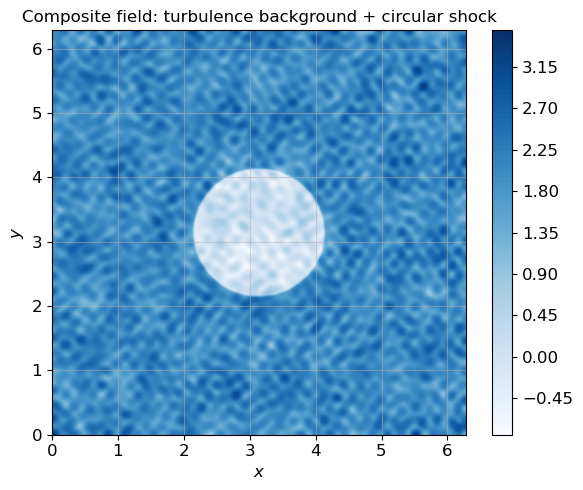

In [23]:
plt.rcParams.update(
    {
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10,
        "figure.titlesize": 16,
        "axes.grid": True,
        "grid.alpha": 0.5,
    }
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(X_grid, Y_grid, u_turb, levels=100, cmap="Blues")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Composite field: turbulence background + circular shock")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Differentiate with `BSPF2D`

We now apply `BSPF2D.partial_x(...)` directly to the synthetic field to compute
the first derivative with respect to `x`. This keeps the notebook as a pure
differentiation benchmark without any additional boundary-value repair.


In [24]:
model_2d = BSPF2D.from_grids(
    x=x,
    y=y,
    degree_x=DEGREE,
    degree_y=DEGREE,
    n_basis_x=N_BASIS,
    n_basis_y=N_BASIS,
    domain_x=tuple(DOMAIN_X),
    domain_y=tuple(DOMAIN_Y),
    use_clustering_x=USE_CLUSTERING,
    use_clustering_y=USE_CLUSTERING,
    clustering_factor_x=CLUSTERING_FACTOR,
    clustering_factor_y=CLUSTERING_FACTOR,
    order_x=DEGREE,
    order_y=DEGREE,
    num_boundary_points_x=NUM_BOUNDARY_POINTS,
    num_boundary_points_y=NUM_BOUNDARY_POINTS,
    correction="spectral",
    use_gpu=False,
)

t_start = time.perf_counter()
u_x_bspf, _ = model_2d.partial_x(
    u_turb,
    order=1,
    lam=REG_PARAM,
)
elapsed_bspf = time.perf_counter() - t_start

error_dx_bspf_l2 = np.sqrt(np.mean((u_x_bspf - u_x_exact) ** 2))
error_dx_bspf_linf = np.max(np.abs(u_x_bspf - u_x_exact))
relative_error_dx_bspf_l2 = error_dx_bspf_l2 / np.sqrt(np.mean(u_x_exact ** 2))

print(f"elapsed: {elapsed_bspf:.3f} s")
print(f"relative L2 error: {relative_error_dx_bspf_l2:.6e}")
print(f"Linf error: {error_dx_bspf_linf:.6e}")


elapsed: 0.234 s
relative L2 error: 3.731581e-12
Linf error: 1.559809e-09


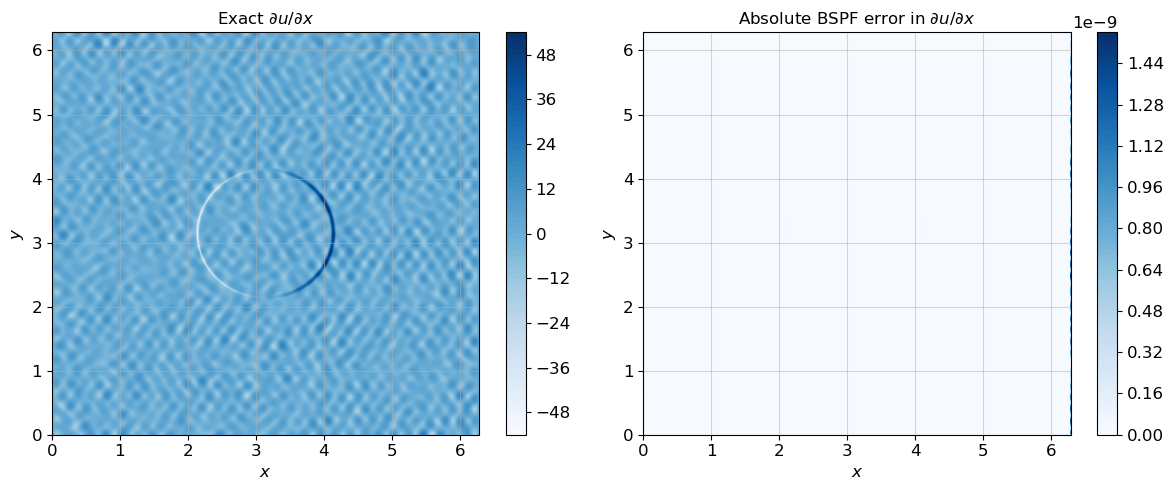

In [25]:
error_dx = np.abs(u_x_bspf - u_x_exact)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].contourf(X_grid, Y_grid, u_x_exact, levels=100, cmap="Blues")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_title("Exact $\\partial u / \\partial x$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_grid, Y_grid, error_dx, levels=100, cmap="Blues")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
axes[1].set_title("Absolute BSPF error in $\\partial u / \\partial x$")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## Convergence Study

To assess how the package behaves under refinement, we repeat the same field
construction and `BSPF2D` differentiation on a sequence of uniform grids. The
error metric is the relative $L^2$ norm of the `∂u/∂x` error.


In [26]:
def run_convergence_study_2d(
    n_points_list,
    domain_x,
    domain_y,
    degree,
    n_basis,
    num_boundary_points,
    reg_param,
    clustering_factor,
    use_clustering,
    n_modes,
    seed,
    shock_enabled,
    shock_params,
):
    Lx = domain_x[1] - domain_x[0]
    Ly = domain_y[1] - domain_y[0]
    errors_bspf_dx_l2 = []
    errors_bspf_dx_linf = []
    dx_list = []
    elapsed_time_list = []

    for N in n_points_list:
        print(f"  Running convergence study: N = {N} x {N}...")
        x = np.linspace(domain_x[0], domain_x[1], N)
        y = np.linspace(domain_y[0], domain_y[1], N)
        X_grid, Y_grid = np.meshgrid(x, y)

        u_turb, u_x_exact = evaluate_turbulence_field_on_grid(x, y, Lx, Ly, n_modes, seed)
        if shock_enabled:
            u_turb, u_x_exact, _, _, _, _ = add_circular_shock_wave(
                X_grid,
                Y_grid,
                u_turb,
                u_x_exact,
                np.zeros_like(u_turb),
                np.zeros_like(u_turb),
                np.zeros_like(u_turb),
                np.zeros_like(u_turb),
                center_x=shock_params["center_x"],
                center_y=shock_params["center_y"],
                radius=shock_params["radius"],
                amplitude=shock_params["amplitude"],
                width=shock_params["width"],
            )

        model_2d = BSPF2D.from_grids(
            x=x,
            y=y,
            degree_x=degree,
            degree_y=degree,
            n_basis_x=n_basis,
            n_basis_y=n_basis,
            domain_x=tuple(domain_x),
            domain_y=tuple(domain_y),
            use_clustering_x=use_clustering,
            use_clustering_y=use_clustering,
            clustering_factor_x=clustering_factor,
            clustering_factor_y=clustering_factor,
            order_x=degree,
            order_y=degree,
            num_boundary_points_x=num_boundary_points,
            num_boundary_points_y=num_boundary_points,
            correction="spectral",
            use_gpu=False,
        )

        t_start = time.perf_counter()
        u_x_bspf, _ = model_2d.partial_x(
            u_turb,
            order=1,
            lam=reg_param,
        )
        elapsed_time_list.append(time.perf_counter() - t_start)

        error_l2 = np.sqrt(np.mean((u_x_bspf - u_x_exact) ** 2))
        exact_l2 = np.sqrt(np.mean(u_x_exact ** 2))
        errors_bspf_dx_l2.append(error_l2 / exact_l2 if exact_l2 > 0.0 else error_l2)
        errors_bspf_dx_linf.append(np.max(np.abs(u_x_bspf - u_x_exact)))
        dx_list.append((domain_x[1] - domain_x[0]) / (N - 1))

    return {
        "dx": np.array(dx_list),
        "elapsed_time": np.array(elapsed_time_list),
        "errors_bspf_dx_l2": np.array(errors_bspf_dx_l2),
        "errors_bspf_dx_linf": np.array(errors_bspf_dx_linf),
    }


min_n = max(64, 2 * TURB_N_MODES)
n_points_list = sorted(list(set([min_n, 128, 256, 512, 1024, 2048])))
shock_params = {
    "center_x": SHOCK_CENTER_X,
    "center_y": SHOCK_CENTER_Y,
    "radius": SHOCK_RADIUS,
    "amplitude": SHOCK_AMPLITUDE,
    "width": SHOCK_WIDTH,
}

conv_results = run_convergence_study_2d(
    n_points_list=n_points_list,
    domain_x=DOMAIN_X,
    domain_y=DOMAIN_Y,
    degree=DEGREE,
    n_basis=N_BASIS,
    num_boundary_points=NUM_BOUNDARY_POINTS,
    reg_param=REG_PARAM,
    clustering_factor=CLUSTERING_FACTOR,
    use_clustering=USE_CLUSTERING,
    n_modes=TURB_N_MODES,
    seed=TURB_SEED,
    shock_enabled=SHOCK_ENABLED,
    shock_params=shock_params,
)

final_dx = conv_results["dx"][-1]
final_error_l2 = conv_results["errors_bspf_dx_l2"][-1]
final_error_linf = conv_results["errors_bspf_dx_linf"][-1]
final_elapsed = conv_results["elapsed_time"][-1]

print("Convergence study final sample:")
print(f"  dx:        {final_dx:.6e}")
print(f"  relative L2 error:  {final_error_l2:.6e}")
print(f"  Linf error:         {final_error_linf:.6e}")
print(f"  elapsed:            {final_elapsed:.3f} s")


  Running convergence study: N = 128 x 128...
  Running convergence study: N = 256 x 256...
  Running convergence study: N = 512 x 512...
  Running convergence study: N = 1024 x 1024...
  Running convergence study: N = 2048 x 2048...
Convergence study final sample:
  dx:        3.069460e-03
  relative L2 error:  3.731581e-12
  Linf error:         1.559809e-09
  elapsed:            0.229 s


## Convergence Plot

The final plot shows the relative $L^2$ error in `∂u/∂x` as a function of grid
spacing `Δx`, together with a first-order reference slope.


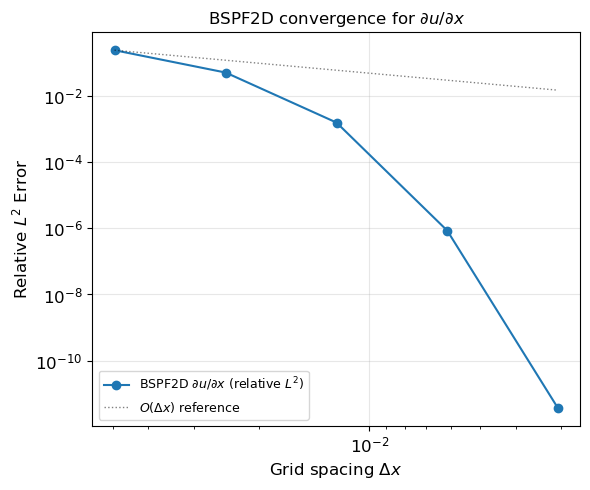

In [27]:
plt.rcParams.update(
    {
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10,
        "figure.titlesize": 16,
        "axes.grid": True,
        "grid.alpha": 0.5,
    }
)

fig, ax = plt.subplots(figsize=(6, 5))
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

dx_values = conv_results["dx"]
ax.loglog(
    dx_values,
    conv_results["errors_bspf_dx_l2"],
    "o-",
    label="BSPF2D $\\partial u/\\partial x$ (relative $L^2$)",
    color=default_colors[0],
    linewidth=1.5,
    markersize=6,
)

if len(dx_values) > 1:
    ref_x = np.array([dx_values[0], dx_values[-1]])
    ref_y = conv_results["errors_bspf_dx_l2"][0] * (ref_x / dx_values[0])
    ax.loglog(ref_x, ref_y, "k:", linewidth=1, alpha=0.5, label="$O(\\Delta x)$ reference")

ax.set_xlabel("Grid spacing $\\Delta x$")
ax.set_ylabel("Relative $L^2$ Error")
ax.legend(fontsize=9)
ax.set_title("BSPF2D convergence for $\\partial u / \\partial x$")
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.show()
